In [54]:
pip install google-genai pillow

Note: you may need to restart the kernel to use updated packages.


In [55]:

from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode,tools_condition

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage,BaseMessage,HumanMessage
from dotenv import load_dotenv
from langgraph.graph.message import add_messages
import operator
from google import genai
from PIL import Image
import io
import os
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated, Optional

from langgraph.types import Send


from langchain_community.tools.tavily_search import TavilySearchResults

load_dotenv()




True

In [56]:
# schemas
class Task(BaseModel):
    title_for_section : str = Field(description="title for the current section")
    content_for_section : str = Field(description="type pf content that should be added in the current section")

In [57]:
class Plan(BaseModel):
    blog_title:str = Field(description="main title for the whole blog most relevent to the topic given by the user")
    list_of_tasks :list[Task] = Field(description="it contain the list of task generated by the orchestrator node so each task will then distributed to the workers")
    
    

In [58]:

class online_result(BaseModel):
    url:str
    title:str
    content:str
    published_on:Optional[str] = None



In [59]:
class online_result_pack(BaseModel):
    evidence: list[online_result]
    


In [60]:
class research_needs(BaseModel):
    do_research:bool
    search_queries: Optional[list[str]]

In [61]:
class section_schema(BaseModel):
    id:int
    title:str
    section_content :str

In [62]:
# # define state
# class Blog_state(TypedDict):
#     topic:str
#     research_needed:bool
#     queries:Optional[list[str]] = []
    
#     evidences:Optional[list[online_result_pack]] = []
    
#     plan:Plan
    
#     sections : Annotated[list[tuple[int,str]],operator.add]
    
#     final:str

In [63]:
class ImageSpec(BaseModel):
    placeholder_id: str = Field(description="unique placeholder id like image_1")
    placeholder_markdown: str = Field(description="exact placeholder text inserted into markdown, e.g. [IMAGE:image_1]")
    where_to_place: str = Field(description="short explanation of where this image should appear in the blog")
    alt_text: str = Field(description="short alt text for the image")
    image_description: str = Field(description="clear visual description for image generation")

class ReducedBlog(BaseModel):
    final_markdown: str = Field(description="full stitched markdown blog with image placeholders inserted in the correct locations")
    images: list[ImageSpec] = Field(description="list of all image placeholders and how each image should look")

In [64]:
class Blog_state(TypedDict):
    topic: str
    research_needed: bool
    queries: Optional[list[str]]
    evidences: Optional[list[online_result]]
    plan: Plan
    sections: Annotated[list[tuple[int, str,str]], operator.add]
    image_specs: Optional[list[ImageSpec]]
    final: str

In [65]:
# define lmm
llm = ChatOpenAI(model="gpt-5.1")

# define graph
g = StateGraph(Blog_state)



In [66]:
# functions
def fan_out(state:Blog_state):
    plan = state["plan"]
    online_results = state.get("evidences",[])
    return [
        Send("workers",{"task":task,"topic" :plan.blog_title,"title":task.title_for_section, "plan":plan,"online_result" : online_results,"id":id}) for id,task in enumerate(plan.list_of_tasks)
    ]
    

def conditional_edge(state:Blog_state):
    if state["research_needed"]:
        return "research"
    else:
        return "orchestrator"

In [67]:
# define node functions

def router(state:Blog_state):  # tell whether research need or not and if needed then also give the search queries
    
    system_prompt = """
    You are a decision-making assistant whose job is to determine whether a user query requires external research (such as internet search, APIs, or tools) or can be answered using internal parametric knowledge.

Your goal is to make a careful and reliable decision.

Return your response in structured format with:
- research_needed: TRUE or FALSE
- search_queries: list of relevant search queries (only if research_needed is TRUE)

Guidelines:

Set research_needed = TRUE if:
- The query requires real-time, recent, or frequently changing information (e.g., news, stock prices, weather, current events).
- The query asks for specific factual data that may not be reliably stored in the model.
- The query involves niche, obscure, or highly detailed information.
- The query explicitly asks to verify, check, or find latest updates.
- The query depends on external sources for correctness or completeness.

Set research_needed = FALSE if:
- The query is conceptual, educational, or explanatory (e.g., definitions, theory, general explanations).
- The query can be answered using stable, widely known knowledge.
- The query involves coding help, algorithms, or standard practices.
- The query does not require up-to-date or external verification.

Additional Rules:
- Be conservative: prefer TRUE if uncertain.
- When research_needed = TRUE, generate 2–5 concise and relevant search queries.
- Do NOT answer the user’s question. Only decide whether research is needed.

Examples:

User: "What is LangGraph?"
→ research_needed: FALSE

User: "Latest news about Nvidia stock today"
→ research_needed: TRUE
→ search_queries: ["Nvidia stock news today", "NVDA latest updates 2026"]

User: "Explain backpropagation in neural networks"
→ research_needed: FALSE

User: "What are the current interest rates in Canada?"
→ research_needed: TRUE
→ search_queries: ["Canada interest rates 2026", "Bank of Canada current rate"]

Make your decision carefully and return only the structured output.
    """
    structured_llm = llm.with_structured_output(research_needs)
    result = structured_llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"now this is the topic given by the user :{state["topic"]}")
    ])
    
    if result.do_research:
        return{
            "research_needed":True,
            "queries" :result.search_queries
        }
    else:
        return{
            "research_needed":False
        }
        
    


In [68]:
# tool = TavilySearchResults(tavily_api_key = os.getenv("TAVILY_API_KEY"),max_results=3)

# result = tool.invoke("what is langchain")
# # result
# print(result)

# structured_llm = llm.with_structured_output(online_result_pack)

# format_text = "\n\n".join([
#         f"Title: {item['title']}\nURL: {item['url']}\nContent: {item['content']}"
#         for item in result
#     ])

# print(format_text)
    
# results = structured_llm.invoke(format_text)
# print(results)



In [69]:

def research(state:Blog_state):
    queries = state.get("queries",[])
    
    tool = TavilySearchResults(tavily_api_key = os.getenv("TAVILY_API_KEY"),max_results=2)
    main_list = []
    for q in queries:
        internet_result = tool.invoke(q)
        main_list.extend(internet_result)
        
    
    structured_llm = llm.with_structured_output(online_result_pack)
    format_text = "\n\n".join([
        f"title: {text['title']}\n"
        f"url: {text['url']}\n"
        f"content: {text['content']}\n"
        f"published_on: {text.get('published_on', 'N/A')}\n" 
        for text in main_list
    ])
    
    result = structured_llm.invoke(format_text)
    
    return {
        "evidences":result.evidence
    }
    
    


In [70]:
def orchestrator(state:Blog_state): 
    structrued_llm = llm.with_structured_output(Plan)
    online_result = state.get("evidences",[])
    
    system_prompt = """
     You are a blog planning assistant.

    Your job is to create a structured blog plan using:
    1. The user's topic
    2. The provided online research results

    You must generate:
    - a strong and relevant blog title
    - a list of section tasks for the blog

    Instructions:
    - Use the user topic as the main focus.
    - Use the online research results to understand the topic better and improve relevance.
    - Create a blog title that is clear, engaging, and closely aligned with the user's topic.
    - Create a logical list of blog sections that together form a complete, well-structured blog.
    - Each task should represent one section of the blog.
    - For each task:
      - `title_for_section` should be the section heading
      - `content_for_section` should clearly describe what that section should cover

    Important rules:
    - Do not write the full blog.
    - Do not include introduction text outside the structured output.
    - Do not invent facts that are not supported by the topic or research results.
    - Make the plan practical, coherent, and suitable for later distribution to worker nodes.
    - The sections should follow a natural reading flow.
    - Avoid duplicate or overlapping sections.
    - Make sure the plan is detailed enough that another writer can write each section clearly.

    Your output must match the required structured schema exactly.
    """
    
    result = structrued_llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"Here are the online result :{online_result} and user topic : {state["topic"]}")
    ])
    
    
    return  {
        "plan":result
    }
    




In [71]:
def workers(payload:dict) ->dict:
   
   system_prompt = """
You are a professional blog writing assistant working inside a structured LLM pipeline.

Your job is to generate content for ONE specific blog section.

You will be given:
- Blog topic
- Full blog plan
- A specific section task (with an id and title)
- Online research results (evidence)

Instructions:

1. Section Focus:
   - Work ONLY on the given section task.
   - Do NOT write the full blog.
   - Do NOT include content from other sections.

2. Use of Research:
   - Use the provided online results as the primary source.
   - Extract relevant insights and facts.
   - Do NOT hallucinate or add unsupported information.

3. Consistency:
   - Follow the blog plan to maintain flow and tone.
   - Ensure your section logically fits within the overall blog.

4. Writing Style:
   - Clear, engaging, and human-like.
   - Well-structured and informative.
   - Avoid repetition and unnecessary filler.

5. Markdown Formatting (MANDATORY):
   - You MUST write the content in proper Markdown format.
   - Use headings (##, ###) where appropriate.
   - Use bullet points or numbered lists if helpful.
   - Keep paragraphs short and readable.
   - Ensure the output is clean and ready to render as Markdown.

6. Structured Output Requirement (VERY IMPORTANT):
   - You are using structured output.
   - You MUST return exactly THREE fields:
     - id → EXACT same id provided in the section task
     - title → EXACT same title provided in the section task
     - content → the generated Markdown content for this section

7. Strict Rules:
   - Do NOT change the id or title.
   - Do NOT include anything outside the structured output.
   - Do NOT mention instructions, plan, or task in the output.

Your goal is to produce a high-quality, publication-ready Markdown section that strictly follows the given inputs.
"""
    
    
    
   structured_llm = llm.with_structured_output(section_schema)
   result = structured_llm.invoke([
      
      SystemMessage(content=system_prompt),
      HumanMessage(content = f" given information task :{payload["task"]} , topic:{payload["topic"]},title:{payload["title"]} , plan:{payload["plan"]}, online_result :{payload["online_result"]}, id:{payload["id"]} ")
   ])
   return {
      "sections": [(result.id, result.title, result.section_content)]
   }
    
  


In [72]:
def reducer(state: Blog_state):
    section_info = state.get("sections", [])
    blog_title = state["plan"].blog_title

    # 1. sort sections by id
    sorted_section_info = sorted(section_info, key=lambda x: x[0])

    # 2. stitch section title and content
    stitched_body = "\n\n".join(
        f"## {title}\n\n{section_content}" 
        for _, title, section_content in sorted_section_info
    )

    # 3. initial markdown before image placement
    raw_markdown = f"# {blog_title}\n\n{stitched_body}"

    system_prompt = """
You are a blog assembly assistant.

Your job is to:
1. Combine the already-written blog sections into one polished final markdown article.
2. Insert image placeholders only where they genuinely improve readability.
3. Return structured output.

Rules:
- Keep the blog title as the main H1 heading.
- Preserve the meaning of the original section content.
- Do not remove important information.
- You may improve transitions slightly so the blog reads smoothly.
- Insert 0 to 4 image placeholders maximum.
- Each placeholder must appear naturally in the markdown.
- Use placeholder format exactly like: [IMAGE:image_1]
- Every placeholder inserted into markdown must have a matching entry in the images list.
- Do not invent fake citations or unsupported facts.
- The final_markdown must contain the full final blog.
- The images list must explain what each image should look like.

For each image:
- placeholder_id must be like image_1, image_2, etc.
- placeholder_markdown must exactly match the placeholder used in the markdown
- where_to_place should briefly explain the location
- alt_text should be short and useful
- image_description should be detailed enough for an image generator

Return only the structured output.
"""

    structured_llm = llm.with_structured_output(ReducedBlog)

    result = structured_llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"""
Topic: {state['topic']}

Blog title: {blog_title}

Plan:
{state['plan']}

Stitched markdown draft:
{raw_markdown}
""")
    ])

    return {
        "final": result.final_markdown,
        "image_specs": result.images
    }

In [73]:
def image_generator(state: Blog_state):
    final_markdown = state["final"]
    image_specs = state.get("image_specs", [])
    
    # If no images were requested, just pass the markdown through
    if not image_specs:
        return {"final": final_markdown}
        
    # Initialize the Gemini Client
    # It automatically picks up the GEMINI_API_KEY from your environment variables
    client = genai.Client()
    
    for spec in image_specs:
        print(f"Generating image for: {spec.placeholder_id}...")
        try:
            # Call the Imagen 3 model via Gemini API
            result = client.models.generate_images(
                model='imagen-3.0-generate-001',
                prompt=spec.image_description,
                config=dict(
                    number_of_images=1,
                    aspect_ratio="16:9", # Good default for blog posts
                    output_mime_type="image/jpeg"
                )
            )
            
            # Extract the image bytes and save to disk
            for generated_image in result.generated_images:
                image_bytes = generated_image.image.image_bytes
                image = Image.open(io.BytesIO(image_bytes))
                
                # Save locally using the placeholder ID as the filename
                file_path = f"{spec.placeholder_id}.jpg"
                image.save(file_path)
                
                # Create the standard Markdown image syntax
                markdown_image_link = f"![{spec.alt_text}]({file_path})"
                
                # Replace the placeholder in the final text
                final_markdown = final_markdown.replace(spec.placeholder_markdown, markdown_image_link)
                
        except Exception as e:
            print(f"Failed to generate {spec.placeholder_id}: {e}")
            # If it fails, remove the placeholder so it doesn't show up in the final blog
            final_markdown = final_markdown.replace(spec.placeholder_markdown, "")

    return {
        "final": final_markdown
    }

In [74]:
# define nodes
g.add_node("router",router)
g.add_node("research",research)
g.add_node("orchestrator",orchestrator)
g.add_node("workers",workers)
g.add_node("reducer",reducer)
g.add_node("image_generator", image_generator)

In [75]:
# define edges
g.add_edge(START,"router")
g.add_conditional_edges("router",conditional_edge,{"research":"research","orchestrator":"orchestrator"})
g.add_edge("research","orchestrator")
g.add_conditional_edges("orchestrator",fan_out,["workers"])
g.add_edge("workers","reducer")
g.add_edge("reducer", "image_generator")
g.add_edge("image_generator", END)

In [76]:
workflow = g.compile()

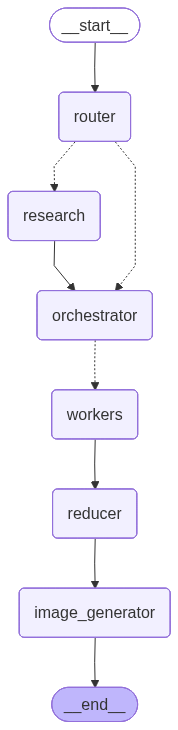

In [77]:
workflow

In [78]:
initial_state = {
    "topic":"what is current going between usa and iran "
}

In [79]:
output = workflow.invoke(initial_state)

C:\Users\ritik\AppData\Local\Temp\ipykernel_3536\679053841.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(tavily_api_key = os.getenv("TAVILY_API_KEY"),max_results=2)


Generating image for: image_1...
Failed to generate image_1: 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/imagen-3.0-generate-001 is not found for API version v1beta, or is not supported for predict. Call ListModels to see the list of available models and their supported methods.', 'status': 'NOT_FOUND'}}
Generating image for: image_2...
Failed to generate image_2: 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/imagen-3.0-generate-001 is not found for API version v1beta, or is not supported for predict. Call ListModels to see the list of available models and their supported methods.', 'status': 'NOT_FOUND'}}
Generating image for: image_3...
Failed to generate image_3: 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/imagen-3.0-generate-001 is not found for API version v1beta, or is not supported for predict. Call ListModels to see the list of available models and their supported methods.', 'status': 'NOT_FOUND'}}


In [80]:
output


{'topic': 'what is current going between usa and iran ',
 'research_needed': True,
 'queries': ['current tensions between USA and Iran',
  'US Iran relations latest developments',
  'recent news on US-Iran conflict 2026',
  'diplomatic relations status United States Iran today'],
 'evidences': [online_result(url='https://www.youtube.com/watch?v=UD3idchhvUk', title='Big Update In War As Trump Hints At Iran De-escalation ... - YouTube', content='U.S. President Donald Trump has hinted at possible de-escalation in the ongoing Iran-US conflict, saying both sides had “very productive', published_on='N/A'),
  online_result(url='https://www.cnn.com/2026/03/23/politics/video/inside-politics-iran-war-nate-swanson', title="Trump says talks are happening. Iran says they're not. Why a former ...", content="Nate Swanson, who previously served on President Trump's Iran negotiator team and as an Iran lead at the National Security Council, joins CNN's Dana Bash on the state of the war amid reports of p

In [81]:
print(output["final"])


# What’s Really Happening Between the United States and Iran Right Now? A Clear, Up‑to‑Date Overview

## Setting the Stage: How the Current U.S.–Iran Standoff Escalated

### A Fragile Relationship Reaches a Breaking Point

The current U.S.–Iran standoff did not appear out of nowhere. It sits on top of years of mistrust and confrontation over Iran’s nuclear program, sweeping U.S. sanctions, and a long list of regional flashpoints.

From Washington’s perspective, Iran’s nuclear advances and support for armed groups around the Middle East have been central concerns. The Council on Foreign Relations’ conflict tracker notes that the confrontation now explicitly involves both the United States and Israel, underscoring how Iran’s regional role and its nuclear activities are seen as linked to a wider security crisis, not just a bilateral dispute.

Tehran, for its part, has treated U.S. sanctions as economic warfare and has pushed back via its regional network of allies and proxy forces. That d

In [82]:
with open("blog_output.md", "w", encoding="utf-8") as file:
    file.write(output["final"])